# Tutorial 4: Melt-and-Quench of Crystalline SiO₂

This tutorial demonstrates the full **7-stage melt-and-quench pipeline** for
generating an amorphous SiO₂ structure from a crystalline input using AmorphGen.

We use a quick protocol suitable for demonstration:
- **Crystalline input:** α-quartz SiO₂ (2×2×2 supercell, 72 atoms)
- **Backend:** CHGNet (fast on CPU; any backend can be substituted)
- **Heating/cooling rate:** ~2000 K/ps (fast, for tutorial speed)
- **Timestep:** 2 fs (allows fewer steps for same simulation time)

**7-stage pipeline:**
1. Structure optimisation (crystalline)
2. Pre-melt equilibration (NPT, 300 K, 4 ps)
3. Melt — heat ramp (NPT, 300 → 2000 K)
4. High-T equilibration (NPT, 2000 K, 4 ps)
5. Quench — cooling ramp (NPT, 2000 → 300 K)
6. Low-T equilibration (NPT, 300 K, 4 ps)
7. Final optimisation (amorphous)

**Estimated runtime:** ~10–15 min on CPU, ~5 min on GPU

In [1]:
# Install if needed (uncomment)
# !pip install -e "..[mace]"
# !pip install matplotlib

import os
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read, write
from ase.data import atomic_masses, atomic_numbers

In [2]:
#!pip install chgnet

---
## 2.1 Prepare the crystalline input

Load α-quartz SiO₂ and build a 2×2×2 supercell (72 atoms).

In [3]:
# Load crystalline SiO2
atoms = read("SiO2_con.cif")
print(f"Unit cell: {atoms.get_chemical_formula()} ({len(atoms)} atoms)")

# Build 2x2x2 supercell
supercell = atoms * (2, 2, 2)
print(f"Supercell: {supercell.get_chemical_formula()} ({len(supercell)} atoms)")
print(f"Cell: {supercell.cell[0,0]:.3f} x {supercell.cell[1,1]:.3f} x {supercell.cell[2,2]:.3f} Å")

# Compute density
total_mass = sum(atomic_masses[atomic_numbers[s]] for s in supercell.get_chemical_symbols())
vol_cm3 = supercell.get_volume() * 1e-24
density = (total_mass / 6.022e23) / vol_cm3
print(f"Density: {density:.3f} g/cm³ (crystalline α-quartz: 2.65 g/cm³)")

# Save as input for the pipeline
write("SiO2_supercell.extxyz", supercell, format="extxyz")
print("\nSaved -> SiO2_supercell.extxyz")

Unit cell: O6Si3 (9 atoms)
Supercell: O48Si24 (72 atoms)
Cell: 9.830 x 8.513 x 10.863 Å
Density: 2.634 g/cm³ (crystalline α-quartz: 2.65 g/cm³)

Saved -> SiO2_supercell.extxyz


## Backend choice — CHGNet for CPU, MACE for GPU

This tutorial is configured to run end-to-end in **~22 minutes on CPU** with CHGNet.

If you have a GPU (CUDA), you can swap to MACE-MPA-0 for higher accuracy by changing the `model` field below to `"mace-mpa-0-medium"` and `device` to `"cuda"`. On CPU, MACE takes 2+ hours for the same pipeline, so we recommend CHGNet for the live tutorial and MACE for production runs on GPU hardware.


---
## 2.2 Load the calculator

We use chgnet as the force engine. You can substitute `"MACE-MPA-0"` or
`"m3gnet"` here — the rest of the tutorial works identically.

In [4]:
from amorphgen.utils import get_calculator

# CHGNet — fast on CPU, also supports Apple MPS GPU
# Options: "cpu", "cuda" (NVIDIA GPU), "mps" (Apple Silicon GPU)
#  device = "cpu"

# Uncomment to try Apple Metal GPU (may not work for all operations):
device = "cpu"

calc = get_calculator(model="chgnet", device=device)
print(f"CHGNet calculator loaded (device: {device}).")

[CHGNet] Loading pretrained model on cpu
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
CHGNet will run on cpu
CHGNet calculator loaded (device: cpu).


---
## 2.3 Run the 7-stage melt-and-quench pipeline

We configure a **quick protocol** for this tutorial:
- NPT ensemble for all MD stages (allows density to adjust)
- ~2000 K/ps heating and cooling rates
- 4 ps equilibration at each temperature
- 2 fs timestep (reduces total steps)
- Melt temperature: 2000 K

For production runs, you would use slower cooling rates (10–100 K/ps),
1 fs timestep, and longer equilibration times (50–100 ps).

> **⚠ This Tutorial** — the structure produced by this protocol is
> good enough to demonstrate the pipeline mechanics and to inspect the
> qualitative crystal-vs-amorphous differences (Si–O CN ≈ 4, O–Si–O angle
> peaked near 109°), but it is **not** a publication-quality amorphous SiO₂
> sample. Specifically:
>
> - **Cooling rate (~2000 K/ps) is too fast compared to literature.**
> - **72 atoms is at the lower edge of "amorphous" cell size.**
> - **A single trajectory is one realisation.** Ensemble properties
>   (mean density, CN distribution, angle distribution width) need ≥10
>   independent quenches from different high-T snapshots — see
>   `--mq-ensemble` in the CLI or Tutorial 5.
> - **Equilibration is short (1 ps stages).** The block-average check below
>   will likely flag stage 4 as not yet equilibrated; that's expected at
>   tutorial scale and is the reason production settings use 50–100 ps.
>
> Section "Production-quality settings" near the end of this notebook lists
> the exact knobs to turn for a publication-grade run.

In [5]:
from amorphgen import MeltQuenchPipeline

pipe = MeltQuenchPipeline(
    input_file="SiO2_supercell.extxyz",
    work_dir="SiO2_melt_quench",
    cfg_override={
        "model": "chgnet",
        "device": device,

        # Stage 1 & 7: optimisation
        "opt": {
            "fmax": 0.1,                # eV/Å — relaxed for tutorial speed
            "max_steps": 100,
        },

        # Stage 2: pre-melt equilibration (NPT, 300 K, 4 ps)
        "eq_premelt": {
            "ensemble": "NVT",
            "T": 300,
            "steps": 1000,              # 1 ps at 1 fs timestep
            "timestep": 1.0,
            "friction": 0.01,
            "ttime": 25.0,
        },

        # Stage 3: melt — heat ramp (NPT, 300 → 2000 K, ~2000 K/ps)
        "melt": {
            "ensemble": "NPT",
            "T_start": 300,
            "T_end": 2000,
            "T_step": 200,              # 200 K per segment
            "steps_per_T": 50,          # 0.05 ps per segment → ~4000 K/ps
            "timestep": 1.0,
            "friction": 0.01,
            "ttime": 25.0,
        },

        # Stage 4: high-T equilibration (NPT, 2000 K, 4 ps)
        "eq_high": {
            "ensemble": "NPT",
            "T": 2000,
            "steps": 1000,              # 1 ps at 1 fs timestep
            "timestep": 1.0,
            "friction": 0.01,
            "ttime": 25.0,
        },

        # Stage 5: quench — cooling ramp (NPT, 2000 → 300 K, ~2000 K/ps)
        "quench": {
            "ensemble": "NPT",
            "T_start": 2000,
            "T_end": 300,
            "T_step": -200,             # -200 K per segment (cooling)
            "steps_per_T": 50,          # 0.05 ps per segment → ~4000 K/ps
            "timestep": 1.0,
            "friction": 0.01,
            "ttime": 25.0,
        },

        # Stage 6: low-T equilibration (NPT, 300 K, 4 ps)
        "eq_low": {
            "ensemble": "NPT",
            "T": 300,
            "steps": 1000,              # 1 ps at 1 fs timestep
            "timestep": 1.0,
            "friction": 0.01,
            "ttime": 25.0,
        },
    },
)

# Run all 7 stages
final_atoms = pipe.run()
print(f"\nFinal structure: {len(final_atoms)} atoms")

[CHGNet] Loading pretrained model on cpu
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
CHGNet will run on cpu

  AmorphGen  v1.0.0  -  Melt-and-Quench Pipeline
  Model:  chgnet
  Device: cpu
  Input:  SiO2_supercell.extxyz
  System: O48Si24 (72 atoms)
  Density: 2.63 g/cm3
  Stages: [1, 2, 3, 4, 5, 6, 7]
  Output: SiO2_melt_quench/


-----------------------------------------------------------------
  Stage 1: Structure optimisation (crystalline)
-----------------------------------------------------------------

[Opt] Using provided Atoms object

  Composition: O48Si24 (72 atoms)
  Initial cell: a=9.8299  b=9.8299  c=10.8626
  Volume: 909.00 A^3  Density: 2.63 g/cm3
  Optimizer: LBFGS  fmax=0.1  max_steps=100
  Cell filter: FrechetCellFilter

   Step      Energy(eV)   Fmax(eV/A)        a(A)        b(A)        c(A)     Vol(A3)
  -------------------------------------------------------------------------------------


/Users/c.kaewmeechai@bham.ac.uk/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/chgnet/model/model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  volumes = torch.tensor(volumes, dtype=TORCH_DTYPE, device=atomic_numbers.device)


      1     -599.881104     0.383822    9.830733    9.830733   10.863449    909.2225
      2     -600.016174     0.210514    9.835972    9.835972   10.868910    910.6494
      3     -600.019592     0.206494    9.836473    9.836473   10.869405    910.7837
      4     -600.074402     0.114626    9.852477    9.852477   10.885230    915.0800
      5     -600.076355     0.121051    9.852836    9.852836   10.885546    915.1734
      6     -600.085205     0.140451    9.855892    9.855892   10.888273    915.9706
      7     -600.099121     0.160137    9.862190    9.862190   10.893884    917.6141
      8     -600.142944     0.283806    9.884297    9.884297   10.913653    923.4054
      9     -600.188721     0.367140    9.911792    9.911792   10.938312    930.6477
     10     -600.253052     0.342643    9.939363    9.939363   10.962983    937.9431
     11     -600.315002     0.275993    9.967011    9.967010   10.987633    945.2891
     12     -600.366394     0.232915    9.994735    9.994735   11

### Equivalent CLI command

The same run can be done from the command line:

```bash
amorphgen SiO2_supercell.extxyz \
    --model chgnet \
    --device cpu \
    --work-dir SiO2_melt_quench \
    --fmax 0.1 \
    --opt-steps 100 \
    --eq-premelt-ensemble NPT \
    --eq-premelt-T 300 \
    --eq-premelt-steps 2000 \
    --melt-ensemble NPT \
    --melt-T-start 300 \
    --melt-T-end 2000 \
    --melt-T-step 200 \
    --melt-steps-per-T 50 \
    --eq-high-ensemble NPT \
    --eq-high-T 2000 \
    --eq-high-steps 2000 \
    --quench-ensemble NPT \
    --quench-T-start 2000 \
    --quench-T-end 300 \
    --quench-T-step -200 \
    --quench-steps-per-T 50 \
    --eq-low-ensemble NPT \
    --eq-low-T 300 \
    --eq-low-steps 2000
```

## Verify the equilibration converged

Before trusting any structural property of the final amorphous structure, it pays to check that the high-T equilibration in stage 4 actually reached steady-state. AmorphGen ships diagnostic helpers in ``amorphgen.utils.equilibration``:

- ``parse_md_log`` reads the per-step columns from a stage log file
- ``block_average_test`` splits the production region into N blocks and reports whether the block-mean energies agree within 2× the standard error (a classical equilibration test)
- ``convergence_report`` runs all the above plus MSD, RDF-by-time-window, and CN-by-time analyses, writing plots to a directory

Quick block-average check on the stage 4 log:

In [6]:
from ase.io import read
from amorphgen.utils.equilibration import parse_md_log, block_average_test

log4 = 'SiO2_melt_quench/stage4_eq.log'   # the high-T equilibration
n_atoms = len(read('SiO2_supercell.extxyz'))

data = parse_md_log(log4)
print(f"Stage 4 log: {len(data['step'])} frames, T_mean = {data['T_K'].mean():.0f} K, "
      f"Epot drift = {(data['Epot_eV'][-1] - data['Epot_eV'][0]) / n_atoms:.4f} eV/atom")

is_eq, info = block_average_test(log4, n_blocks=4, discard_fraction=0.2, n_atoms=n_atoms)
print(f"\nBlock-average test: equilibrated = {is_eq}")
print(f"  block means: {info['block_means']}")
print(f"  overall mean ± 2*SEM: {info['overall_mean']:.4f} ± {2*info['sem']:.4f} eV")
if not is_eq:
    print("  -> Consider extending stage 4 (longer eq_high.steps) before quenching.")
else:
    print("  -> Stage 4 reached steady-state; safe to proceed to quench.")

Stage 4 log: 11 frames, T_mean = 2132 K, Epot drift = -1.1429 eV/atom

Block-average test: equilibrated = False
  block means: [-7.75676875 -7.91110347 -7.88112014 -7.88641875]
  overall mean ± 2*SEM: -7.8623 ± 0.0437 eV
  -> Consider extending stage 4 (longer eq_high.steps) before quenching.


---
## 2.4 Compare crystalline vs amorphous structure

### Density comparison

In [7]:
def get_density(atoms):
    total_mass = sum(atomic_masses[atomic_numbers[s]] for s in atoms.get_chemical_symbols())
    vol_cm3 = atoms.get_volume() * 1e-24
    return (total_mass / 6.022e23) / vol_cm3

crystal = read("SiO2_supercell.extxyz")
amorphous = read("SiO2_melt_quench/stage7_opt.cif")

rho_crystal = get_density(crystal)
rho_amorphous = get_density(amorphous)
reduction = (1 - rho_amorphous / rho_crystal) * 100

print(f"{'Structure':<20s}  {'Atoms':>6s}  {'Density (g/cm³)':>16s}")
print("-" * 50)
print(f"{'Crystalline':<20s}  {len(crystal):6d}  {rho_crystal:16.3f}")
print(f"{'Amorphous':<20s}  {len(amorphous):6d}  {rho_amorphous:16.3f}")
print(f"\nDensity reduction: {reduction:.1f}%")
print(f"Experimental amorphous SiO₂: ~2.20 g/cm³ (fused silica)")

Structure              Atoms   Density (g/cm³)
--------------------------------------------------
Crystalline               72             2.634
Amorphous                 72             2.497

Density reduction: 5.2%
Experimental amorphous SiO₂: ~2.20 g/cm³ (fused silica)


### Radial Distribution Function (RDF)

The RDF is the primary structural fingerprint for amorphous materials.
Key features of amorphous SiO₂:
- **Si–O peak** at ~1.62 Å (tetrahedral bond)
- **O–O peak** at ~2.63 Å (edge of SiO₄ tetrahedron)
- **Si–Si peak** at ~3.12 Å (corner-sharing tetrahedra)
- Loss of long-range order beyond ~5 Å

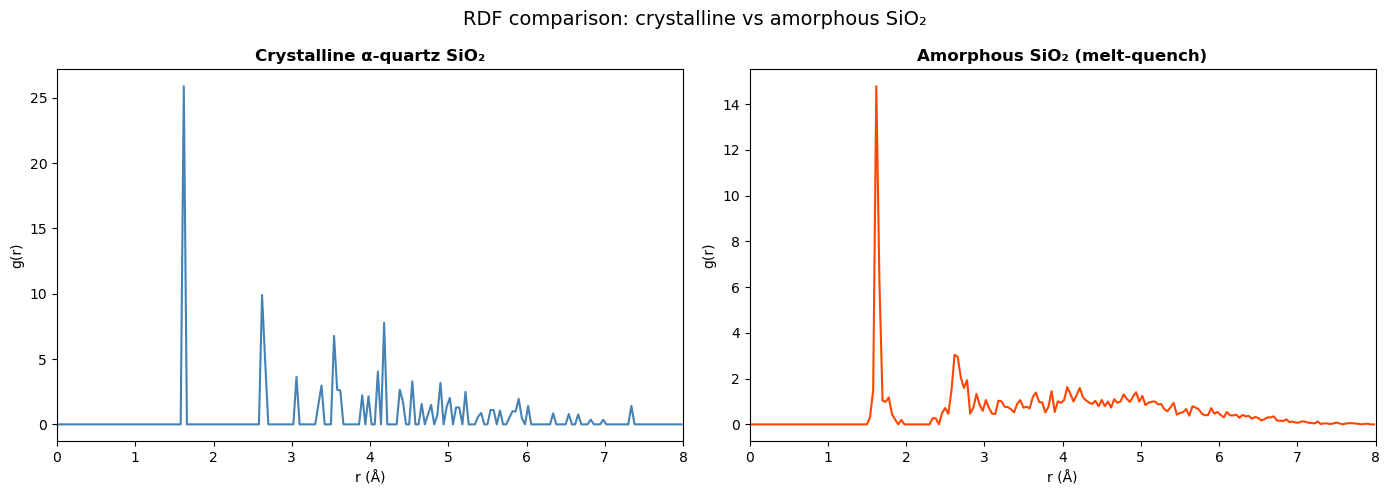

Saved -> rdf_comparison_SiO2.png


In [8]:
def compute_rdf(atoms, rmax=8.0, nbins=200):
    """Compute the total radial distribution function."""
    d = atoms.get_all_distances(mic=True)
    np.fill_diagonal(d, np.inf)
    pairs = d[np.triu_indices_from(d, k=1)]
    pairs = pairs[pairs < rmax]
    hist, edges = np.histogram(pairs, bins=nbins, range=(0, rmax))
    r = 0.5 * (edges[:-1] + edges[1:])
    dr = edges[1] - edges[0]
    n = len(atoms)
    vol = atoms.get_volume()
    n_pairs = n * (n - 1) / 2
    shell_vol = 4 * np.pi * r**2 * dr
    g_r = hist * vol / (n_pairs * shell_vol)
    return r, g_r

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Crystalline
r_c, g_c = compute_rdf(crystal)
ax1.plot(r_c, g_c, color="steelblue", lw=1.5)
ax1.set_title("Crystalline α-quartz SiO₂", fontweight="bold")
ax1.set_xlabel("r (Å)")
ax1.set_ylabel("g(r)")
ax1.set_xlim(0, 8)

# Amorphous
r_a, g_a = compute_rdf(amorphous)
ax2.plot(r_a, g_a, color="orangered", lw=1.5)
ax2.set_title("Amorphous SiO₂ (melt-quench)", fontweight="bold")
ax2.set_xlabel("r (Å)")
ax2.set_ylabel("g(r)")
ax2.set_xlim(0, 8)

fig.suptitle("RDF comparison: crystalline vs amorphous SiO₂", fontsize=14)
plt.tight_layout()
plt.savefig("rdf_comparison_SiO2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> rdf_comparison_SiO2.png")

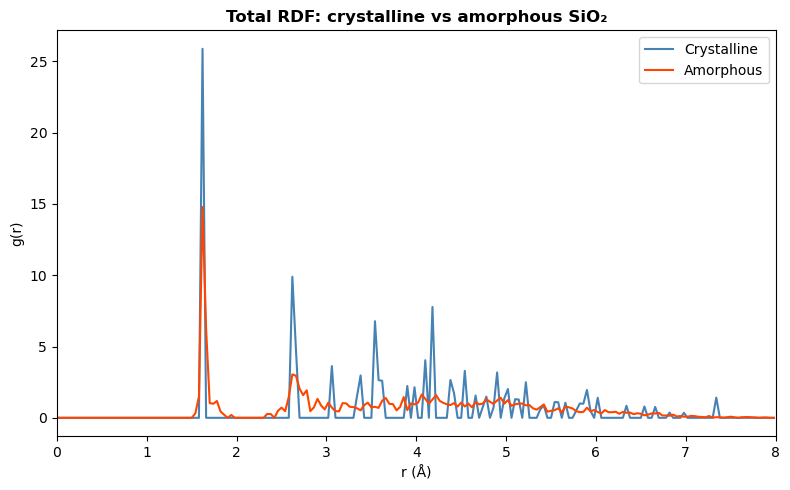

Saved -> rdf_overlay_SiO2.png


In [9]:
# Overlay RDF on single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(r_c, g_c, color="steelblue", lw=1.5, label="Crystalline")
ax.plot(r_a, g_a, color="orangered", lw=1.5, label="Amorphous")

ax.set_xlabel("r (Å)")
ax.set_ylabel("g(r)")
ax.set_title("Total RDF: crystalline vs amorphous SiO₂", fontweight="bold")
ax.set_xlim(0, 8)
ax.legend()
plt.tight_layout()
plt.savefig("rdf_overlay_SiO2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> rdf_overlay_SiO2.png")

### Coordination number analysis

In crystalline SiO₂, Si is 4-coordinated by O (tetrahedral).
This tetrahedral motif is largely preserved in the amorphous phase.

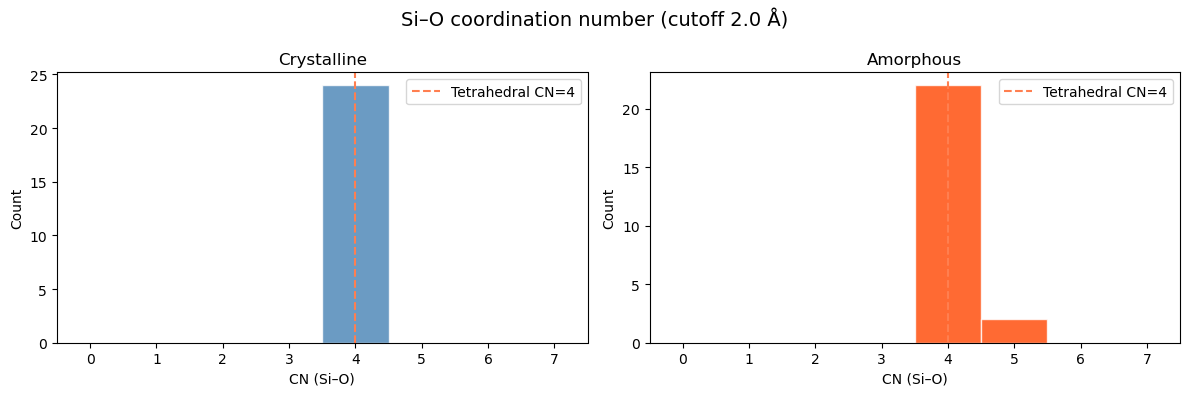

Crystalline — mean CN: 4.00 ± 0.00
Amorphous   — mean CN: 4.08 ± 0.28
Expected    — CN = 4 (tetrahedral)


In [10]:
from ase.neighborlist import neighbor_list

def coordination_numbers(atoms, central, neighbour, cutoff):
    """Compute CN of 'central' atoms surrounded by 'neighbour' atoms."""
    i_arr, j_arr = neighbor_list('ij', atoms, cutoff)
    syms = np.array(atoms.get_chemical_symbols())
    central_idx = np.where(syms == central)[0]
    cn = np.zeros(len(central_idx), dtype=int)
    for k, ci in enumerate(central_idx):
        mask = (i_arr == ci) & (syms[j_arr] == neighbour)
        cn[k] = np.sum(mask)
    return cn

cutoff_SiO = 2.0  # Å — first coordination shell for Si-O

cn_crystal = coordination_numbers(crystal, "Si", "O", cutoff_SiO)
cn_amorphous = coordination_numbers(amorphous, "Si", "O", cutoff_SiO)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(cn_crystal, bins=range(0, 8), align="left",
         color="steelblue", edgecolor="white", alpha=0.8)
ax1.axvline(4, ls="--", color="coral", label="Tetrahedral CN=4")
ax1.set_xlabel("CN (Si–O)")
ax1.set_ylabel("Count")
ax1.set_title("Crystalline")
ax1.legend()
ax1.set_xlim(-0.5, 7.5)

ax2.hist(cn_amorphous, bins=range(0, 8), align="left",
         color="orangered", edgecolor="white", alpha=0.8)
ax2.axvline(4, ls="--", color="coral", label="Tetrahedral CN=4")
ax2.set_xlabel("CN (Si–O)")
ax2.set_ylabel("Count")
ax2.set_title("Amorphous")
ax2.legend()
ax2.set_xlim(-0.5, 7.5)

fig.suptitle(f"Si–O coordination number (cutoff {cutoff_SiO} Å)", fontsize=14)
plt.tight_layout()
plt.savefig("cn_comparison_SiO2.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Crystalline — mean CN: {np.mean(cn_crystal):.2f} ± {np.std(cn_crystal):.2f}")
print(f"Amorphous   — mean CN: {np.mean(cn_amorphous):.2f} ± {np.std(cn_amorphous):.2f}")
print(f"Expected    — CN = 4 (tetrahedral)")

### Bond angle distribution (O–Si–O)

In tetrahedral SiO₄, the ideal O–Si–O angle is 109.47°.
The amorphous phase should show a distribution centred near this value.

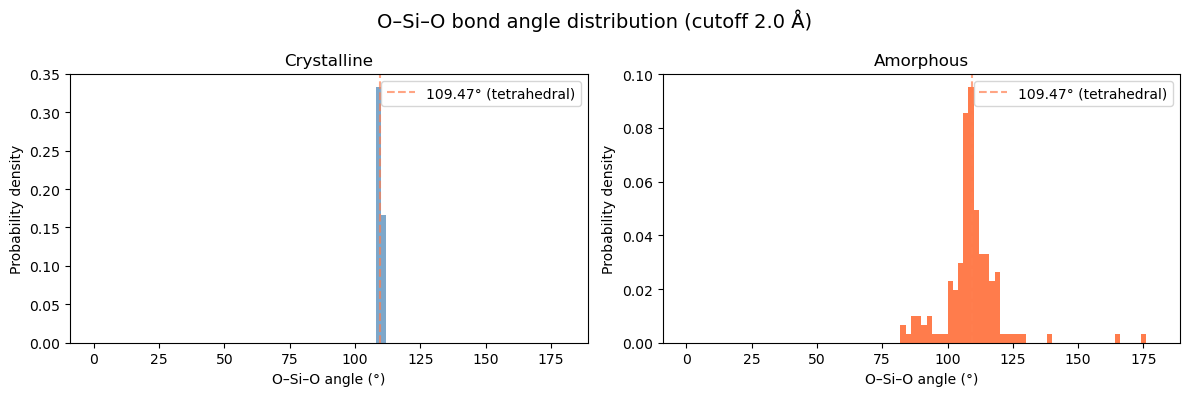

In [11]:
def bond_angles(atoms, central, neighbour, cutoff):
    """Compute neighbour-central-neighbour angles."""
    i_arr, j_arr, d_arr, D_arr = neighbor_list('ijdD', atoms, cutoff)
    syms = np.array(atoms.get_chemical_symbols())
    central_idx = np.where(syms == central)[0]
    angles = []
    for ci in central_idx:
        mask = (i_arr == ci) & (syms[j_arr] == neighbour)
        vecs = D_arr[mask]
        n_nbr = len(vecs)
        for a in range(n_nbr):
            for b in range(a + 1, n_nbr):
                cos_angle = np.dot(vecs[a], vecs[b]) / (
                    np.linalg.norm(vecs[a]) * np.linalg.norm(vecs[b]))
                cos_angle = np.clip(cos_angle, -1, 1)
                angles.append(np.degrees(np.arccos(cos_angle)))
    return np.array(angles)

angles_crystal = bond_angles(crystal, "Si", "O", cutoff_SiO)
angles_amorphous = bond_angles(amorphous, "Si", "O", cutoff_SiO)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(angles_crystal, bins=90, range=(0, 180),
         color="steelblue", edgecolor="none", alpha=0.7, density=True)
ax1.axvline(109.47, ls="--", color="coral", alpha=0.7, label="109.47° (tetrahedral)")
ax1.set_xlabel("O–Si–O angle (°)")
ax1.set_ylabel("Probability density")
ax1.set_title("Crystalline")
ax1.legend()

ax2.hist(angles_amorphous, bins=90, range=(0, 180),
         color="orangered", edgecolor="none", alpha=0.7, density=True)
ax2.axvline(109.47, ls="--", color="coral", alpha=0.7, label="109.47° (tetrahedral)")
ax2.set_xlabel("O–Si–O angle (°)")
ax2.set_ylabel("Probability density")
ax2.set_title("Amorphous")
ax2.legend()

fig.suptitle(f"O–Si–O bond angle distribution (cutoff {cutoff_SiO} Å)", fontsize=14)
plt.tight_layout()
plt.savefig("angles_SiO2.png", dpi=150, bbox_inches="tight")
plt.show()

### Summary

In [23]:
print(f"{'Property':<30s}  {'Crystalline':>14s}  {'Amorphous':>14s}  {'Experimental':>14s}")
print("-" * 78)
print(f"{'Density (g/cm³)':<30s}  {rho_crystal:14.3f}  {rho_amorphous:14.3f}  {'~2.20':>14s}")
print(f"{'Mean Si-O CN':<30s}  {np.mean(cn_crystal):14.2f}  {np.mean(cn_amorphous):14.2f}  {'4.0':>14s}")
print(f"{'Mean O-Si-O angle (°)':<30s}  {np.mean(angles_crystal):14.1f}  {np.mean(angles_amorphous):14.1f}  {'109.47':>14s}")
print(f"\nNote: This is a quick tutorial run (~2000 K/ps cooling, 72-atom cell, single seed, CHGNet).")
print(f"The density (~2.5 vs experimental ~2.20 g/cm³) is the main visible effect of the")
print(f"tutorial-grade settings. See the 'Production-quality settings' section below for the")
print(f"four knobs (cell size, eq time, cooling rate, ensemble) needed for a publication run.")

Property                           Crystalline       Amorphous    Experimental
------------------------------------------------------------------------------
Density (g/cm³)                          2.634           2.497           ~2.20
Mean Si-O CN                              4.00            4.08             4.0
Mean O-Si-O angle (°)                    109.5           109.0          109.47

Note: This is a quick tutorial run (~2000 K/ps cooling, 72-atom cell, single seed, CHGNet).
The density (~2.5 vs experimental ~2.20 g/cm³) is the main visible effect of the
tutorial-grade settings. See the 'Production-quality settings' section below for the
four knobs (cell size, eq time, cooling rate, ensemble) needed for a publication run.


---
## Note: Production-quality settings

The quick protocol above uses fast heating/cooling (~2000 K/ps), short
equilibration (1 ps), and a small 72-atom cell — all chosen so the tutorial
runs end-to-end in ~15 min. For research-quality amorphous SiO₂ structures,
the four knobs that matter most (and the reasons each matters) are:

| Knob | Tutorial value | Production target | Why it matters |
|---|---|---|---|
| **Cell size** | 72 atoms (2×2×2 supercell) | 200–500 atoms (3×3×3 or larger) | Ring statistics, intermediate-range order, and structure factor S(Q) at small Q all suffer from finite-size artefacts below ~200 atoms. The first sharp diffraction peak of a-SiO₂ at Q ≈ 1.5 Å⁻¹ probes ~4 Å length scales — your cell needs to be a few times larger than that. |
| **Equilibration time** | 1 ps per eq stage | 50–100 ps per eq stage | Short equilibration leaves memory of the initial configuration. The block-average diagnostic in section "Verify the equilibration converged" will tell you when stage 4 has actually reached steady state. |
| **Cooling rate** | ~2000 K/ps | 10–100 K/ps (20–200× slower) | The MD cooling rate is already ~10⁹–10¹³ × faster than lab quenching. Slower MD quenches give the network more time to relax into lower-energy configurations and bring the final density closer to experiment (~2.20 g/cm³ for fused silica). |
| **Ensemble of quenches** | 1 trajectory | 3–10 independent quenches | A single trajectory is one realisation. Ensemble means / standard deviations on density, CN distribution, and angle distribution are needed for any quantitative claim. See `--mq-ensemble` (CLI) or Tutorial 5 (hybrid random + batch quench). |

A production-quality `MeltQuenchPipeline` configuration:

```python
pipe = MeltQuenchPipeline(
    input_file="SiO2_supercell_3x3x3.extxyz",   # 243 atoms (3x3x3 of α-quartz)
    work_dir="SiO2_production",
    cfg_override={
        "model": "mace-mpa-0",         # MACE for higher accuracy on oxides
        "device": "cuda",

        "opt": {"fmax": 0.01, "max_steps": 1000},

        "eq_premelt": {"ensemble": "NPT", "T": 300, "steps": 50000},       # 50 ps

        "melt": {
            "ensemble": "NPT", "T_start": 300, "T_end": 3000,
            "T_step": 100, "steps_per_T": 1000,                             # 100 K/ps
        },

        "eq_high": {"ensemble": "NPT", "T": 3000, "steps": 100000},        # 100 ps

        "quench": {
            "ensemble": "NPT", "T_start": 3000, "T_end": 300,
            "T_step": -100, "steps_per_T": 1000,                            # 100 K/ps
        },

        "eq_low": {"ensemble": "NPT", "T": 300, "steps": 50000},           # 50 ps
    },
)
```

For an ensemble, use the CLI's integrated mode:

```bash
amorphgen SiO2_supercell_3x3x3.extxyz \
    --model mace-mpa-0 --device cuda \
    --mq-ensemble --n-quenches 5 \
    --quench-T-step -100 --quench-steps-per-T 1000 \
    --work-dir SiO2_ensemble
```

This runs stages 1–4 once, then 5 independent quenches (stages 5–7) from
different stage-4 snapshots, collecting all 5 amorphous structures into
`SiO2_ensemble/final/` for downstream statistical analysis.

---
## Output summary

After running this tutorial, you should have:

```
SiO2_supercell.extxyz                    # 2x2x2 crystalline input
SiO2_melt_quench/
├── opt_stage.log                        # Stage 1 optimisation log
├── opt_stage.traj                       # Stage 1 trajectory
├── opt_final.cif                        # Stage 1 optimised crystal
├── stage2_eq.log                        # Stage 2 pre-melt eq log
├── stage2_eq.extxyz                     # Stage 2 trajectory + output
├── stage3_melt.log                      # Stage 3 melt log
├── stage3_melt.extxyz                   # Stage 3 trajectory
├── stage4_eq.log                        # Stage 4 high-T eq log
├── stage4_eq.extxyz                     # Stage 4 trajectory + output
├── stage5_quench.log                    # Stage 5 quench log
├── stage5_quench.extxyz                 # Stage 5 trajectory
├── stage6_eq.log                        # Stage 6 low-T eq log
├── stage6_eq.extxyz                     # Stage 6 trajectory + output
├── opt_stage.log                        # Stage 7 optimisation log
├── opt_final.cif                        # Stage 7 final amorphous structure
└── stage7_amorphous_final.cif           # Final output
rdf_comparison_SiO2.png
rdf_overlay_SiO2.png
cn_comparison_SiO2.png
angles_SiO2.png
```

Open `stage7_amorphous_final.cif` in VESTA to visualise the amorphous structure.